In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load your datasets
true_df = pd.read_csv('True.csv')
fake_df = pd.read_csv('Fake.csv')

# Assign labels: 0 for Real news, 1 for Fake news
true_df['label'] = 0
fake_df['label'] = 1

# Combine them into one dataframe
df = pd.concat([true_df, fake_df]).reset_index(drop=True)

# Select only the columns we need
df = df[['text', 'label']]

In [2]:
# X is the input (the news text)
# y is the output (the 0 or 1 label)
X = df['text']
y = df['label']

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 35918
Testing samples: 8980


In [3]:
# Initialize the vectorizer
# 'stop_words' removes common English filler words
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

# Learn the vocabulary from the training data and transform it
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform the test data using the same vocabulary
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
# Initialize the model
nb_classifier = MultinomialNB()

# Train the model using the training data
nb_classifier.fit(X_train_tfidf, y_train)

MultinomialNB()

In [ ]:
# Predict labels for the unseen test data
y_pred = nb_classifier.predict(X_test_tfidf)

# Calculate the percentage of correct guesses
accuracy = accuracy_score(y_test, y_pred)

print(f"--- Model Accuracy: {accuracy * 100:.2f}% ---")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))

--- Model Accuracy: 93.51% ---

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      4330
           1       0.94      0.94      0.94      4650

    accuracy                           0.94      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.94      0.94      0.94      8980



In [ ]:
print("First 10 Test Samples and their Predictions:")
for i in range(10):
    print(f"\nSample {i+1}:")
    print(f"Text: {X_test.iloc[i][:200]}...")
    print(f"Predicted Label: {y_pred[i]} (0: Real, 1: Fake)")

First 10 Test Samples and their Predictions:

Sample 1:
Text: Donald Trump s White House is in chaos, and they are trying to cover it up. Their Russia problems are mounting by the hour, and they refuse to acknowledge that there are problems surrounding all of th...
Predicted Label: 1 (0: Real, 1: Fake)

Sample 2:
Text: Now that Donald Trump is the presumptive GOP nominee, it s time to remember all those other candidates who tried so hard to beat him in the race to the White House. After all, how can we forget all th...
Predicted Label: 1 (0: Real, 1: Fake)

Sample 3:
Text: Mike Pence is a huge homophobe. He supports ex-gay conversion therapy, opposes hate crimes protections for LGBTQ people, is staunchly against marriage equality, and once said that he believes that sam...
Predicted Label: 1 (0: Real, 1: Fake)

Sample 4:
Text: SAN FRANCISCO (Reuters) - California Attorney General Xavier Becerra said on Friday he was “prepared to take whatever action it takes” to defend the Obamacare ma

In [ ]:
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
X = df['text']
y = df['label']

# Segmenting the data: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english', max_df=0.7)

# Transform the text data
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
# Initialize the SVM Classifier with a linear kernel
svm_model = SVC(kernel='linear')

# Train the model (this may take 1-2 minutes depending on dataset size)
svm_model.fit(X_train_tfidf, y_train)

SVC(kernel='linear')

In [ ]:
# Make predictions
y_pred_svm = svm_model.predict(X_test_tfidf)

# Check Accuracy
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 99.16%

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      4330
           1       1.00      0.99      0.99      4650

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Initialize the Tokenizer
# num_words=10000 keeps only the 10,000 most frequent words
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# 2. Convert text to sequences of integers
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

# 3. Pad sequences so they are all the same length (e.g., 300 words)
max_length = 300
X_train_padded = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
X_test_padded = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout, Input

model = Sequential([
    # This 'Input' layer tells the model the shape upfront
    Input(shape=(max_length,)),

    # Remove 'input_length' from here to stop the warning
    Embedding(input_dim=10000, output_dim=64),

    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Now this will show the correct shapes and parameters!
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 706,177 (2.69 MB)

 Trainable params: 706,177 (2.69 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Convert labels to numpy arrays for TensorFlow
import numpy as np
y_train_final = np.array(y_train)
y_test_final = np.array(y_test)

# Train the model
history = model.fit(
    X_train_padded, y_train_final,
    epochs=5,
    validation_data=(X_test_padded, y_test_final),
    batch_size=64
)

Epoch 1/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.9884 - loss: 0.0503 - val_accuracy: 0.9986 - val_loss: 0.0065
Epoch 2/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.9996 - loss: 0.0023 - val_accuracy: 0.9989 - val_loss: 0.0056
Epoch 3/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.9997 - loss: 0.0018 - val_accuracy: 0.9990 - val_loss: 0.0061
Epoch 4/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.9996 - loss: 0.0016 - val_accuracy: 0.9983 - val_loss: 0.0104
Epoch 5/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.9998 - loss: 0.0014 - val_accuracy: 0.9986 - val_loss: 0.0083


In [ ]:
# Evaluate on test data
loss, accuracy = model.evaluate(X_test_padded, y_test_final)
print(f"LSTM Test Accuracy: {accuracy * 100:.2f}%")

# Make predictions (0.5 threshold)
y_pred_lstm = (model.predict(X_test_padded) > 0.5).astype("int32")

281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9986 - loss: 0.0083
LSTM Test Accuracy: 99.86%
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [8]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
from sklearn.model_selection import train_test_split

# --- LOAD DATA ---
true_df = pd.read_csv('True.csv')
fake_df = pd.read_csv('Fake.csv')
true_df['label'], fake_df['label'] = 0, 1
df = pd.concat([true_df, fake_df]).reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)

# Tokenization
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=300)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=300)
vocab_size = len(tokenizer.word_index) + 1

# --- OPTION A: WORD2VEC + LSTM ---
w2v_model = Word2Vec([s.split() for s in X_train], vector_size=100, window=5, min_count=1)
w2v_matrix = np.zeros((vocab_size, 100))
for word, i in tokenizer.word_index.items():
    if word in w2v_model.wv: w2v_matrix[i] = w2v_model.wv[word]

model_w2v = Sequential([
    Embedding(vocab_size, 100, weights=[w2v_matrix], input_length=300, trainable=False),
    Bidirectional(LSTM(64)),
    Dense(1, activation='sigmoid')
])
model_w2v.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Training ISOT with Word2Vec...")
model_w2v.fit(X_train_seq, y_train, epochs=3, batch_size=64)

# --- OPTION B: GLOVE + LSTM ---
glove_index = {}
with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        v = line.split(); glove_index[v[0]] = np.asarray(v[1:], dtype='float32')

glove_matrix = np.zeros((vocab_size, 100))
for word, i in tokenizer.word_index.items():
    if word in glove_index: glove_matrix[i] = glove_index[word]

model_glove = Sequential([
    Embedding(vocab_size, 100, weights=[glove_matrix], input_length=300, trainable=False),
    Bidirectional(LSTM(64)),
    Dense(1, activation='sigmoid')
])
model_glove.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Training ISOT with GloVe...")
model_glove.fit(X_train_seq, y_train, epochs=3, batch_size=64)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training ISOT with Word2Vec...
Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.9513 - loss: 0.1361
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9741 - loss: 0.0729
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.9845 - loss: 0.0469
Training ISOT with GloVe...
Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.9222 - loss: 0.2038
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9538 - loss: 0.1295
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9771 - loss: 0.0691


In [5]:
!pip install -q -U gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.4 MB/s eta 0:00:00


In [7]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

--2026-03-31 19:02:23--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-31 19:02:23--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-31 19:02:23--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

281/281 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
--- Word2Vec + LSTM Performance ---
Accuracy: 0.9844
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4330
           1       0.99      0.98      0.98      4650

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980


--- GloVe + LSTM Performance ---
Accuracy: 0.9774
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      4330
           1       0.99      0.96      0.98      4650

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



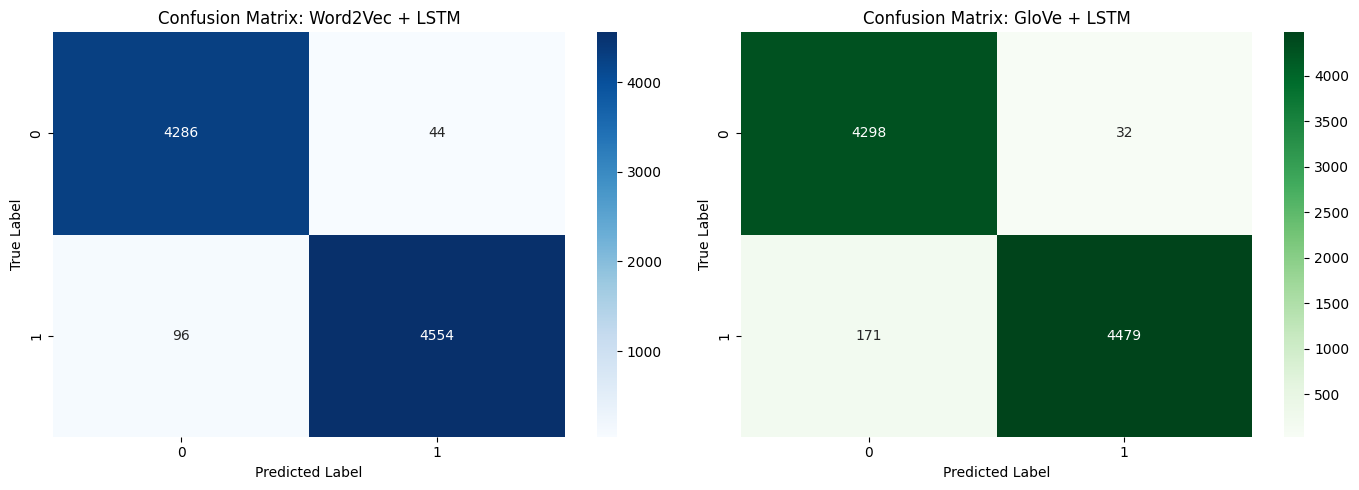

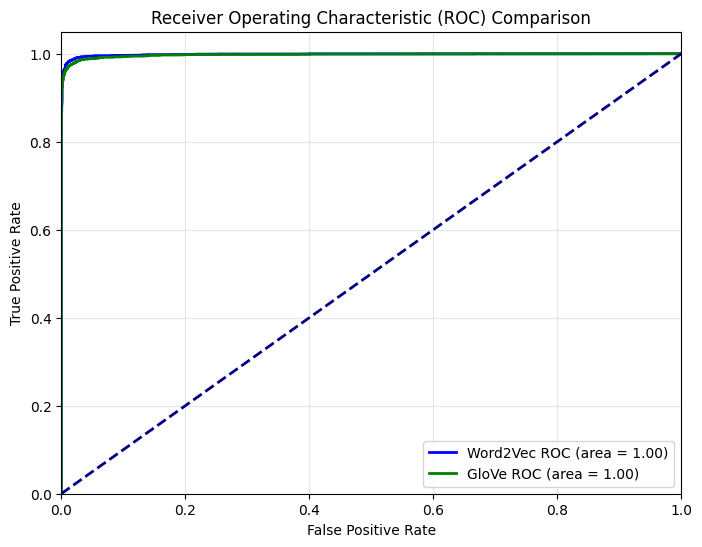

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, classification_report

# 1. Generate Predictions
# Word2Vec Model
y_pred_prob_w2v = model_w2v.predict(X_test_seq)
y_pred_w2v = (y_pred_prob_w2v > 0.5).astype("int32")

# GloVe Model
y_pred_prob_glove = model_glove.predict(X_test_seq)
y_pred_glove = (y_pred_prob_glove > 0.5).astype("int32")

# 2. Print Accuracy and Classification Reports
print("--- Word2Vec + LSTM Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_w2v):.4f}")
print(classification_report(y_test, y_pred_w2v))

print("\n--- GloVe + LSTM Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_glove):.4f}")
print(classification_report(y_test, y_pred_glove))

# 3. Plot Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Word2Vec Confusion Matrix
cm_w2v = confusion_matrix(y_test, y_pred_w2v)
sns.heatmap(cm_w2v, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix: Word2Vec + LSTM')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# GloVe Confusion Matrix
cm_glove = confusion_matrix(y_test, y_pred_glove)
sns.heatmap(cm_glove, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Confusion Matrix: GloVe + LSTM')
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# 4. Plot Combined ROC Curves
plt.figure(figsize=(8, 6))

# Word2Vec ROC
fpr_w2v, tpr_w2v, _ = roc_curve(y_test, y_pred_prob_w2v)
roc_auc_w2v = auc(fpr_w2v, tpr_w2v)
plt.plot(fpr_w2v, tpr_w2v, color='blue', lw=2, label=f'Word2Vec ROC (area = {roc_auc_w2v:.2f})')

# GloVe ROC
fpr_glove, tpr_glove, _ = roc_curve(y_test, y_pred_prob_glove)
roc_auc_glove = auc(fpr_glove, tpr_glove)
plt.plot(fpr_glove, tpr_glove, color='green', lw=2, label=f'GloVe ROC (area = {roc_auc_glove:.2f})')

# Plot baseline
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [10]:
!pip install -q transformers datasets accelerate
import torch
import gc
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [12]:
!pip install transformers torch

In [13]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def train_transformer(model_name, name):
    print(f"\n🚀 Training {name}...")

    # 🔥 MEMORY SAFE SETTINGS
    BATCH_SIZE = 4
    MAX_LEN = 32
    ACCUM_STEPS = 4

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # tokenize
    train_enc = tokenizer(
        X_train.tolist(),
        truncation=True,
        padding=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

    test_enc = tokenizer(
        X_test.tolist(),
        truncation=True,
        padding=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

    scaler = torch.cuda.amp.GradScaler()

    model.train()

    y_train_np = y_train.values
    y_test_np = y_test.values

    # 🔥 TRAINING LOOP
    for epoch in range(1):
        optimizer.zero_grad()

        for step, i in enumerate(range(0, len(X_train), BATCH_SIZE)):

            batch_input = {
                k: v[i:i+BATCH_SIZE].to(device)
                for k, v in train_enc.items()
            }

            batch_labels = torch.tensor(
                y_train_np[i:i+BATCH_SIZE],
                dtype=torch.long
            ).to(device)

            with torch.cuda.amp.autocast():
                outputs = model(**batch_input, labels=batch_labels)
                loss = outputs.loss / ACCUM_STEPS

            scaler.scale(loss).backward()

            if (step + 1) % ACCUM_STEPS == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        print(f"Epoch {epoch+1} done ✅")

    # 🔥 EVALUATION
    model.eval()
    test_enc = {k: v.to(device) for k, v in test_enc.items()}

    with torch.no_grad():
        outputs = model(**test_enc)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[:, 1]

    # simple accuracy
    preds = (probs > 0.5).astype(int)
    acc = (preds == y_test_np).mean()

    print(f"{name} Accuracy: {acc:.4f}")

    # 🔥 FREE MEMORY
    del model
    torch.cuda.empty_cache()

Using device: cuda


In [14]:
train_transformer("roberta-base", "RoBERTa")


🚀 Training RoBERTa...


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_12900/4181429097.py:42: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please

Epoch 1 done ✅
RoBERTa Accuracy: 0.9988


In [ ]:
train_transformer("albert-base-v2", "ALBERT")


🚀 Training ALBERT...


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_12900/4181429097.py:42: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_12900/4181429097.

Epoch 1 done ✅


OutOfMemoryError: CUDA out of memory. Tried to allocate 3.29 GiB. GPU 0 has a total capacity of 14.56 GiB of which 2.05 GiB is free. Including non-PyTorch memory, this process has 12.51 GiB memory in use. Of the allocated memory 11.81 GiB is allocated by PyTorch, and 47.40 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)